# ANÁLISIS COMPLETO "clientes_credito"

## 1. Entendimiento del dataset

|Columna|Descripción|
|---    |---                |
|**ID** | ID de cada cliente|
|**LIMIT_BAL**| Monto del crédito otorgado en dólares NT (incluye crédito individual y familiar/complementario)|
|**SEXO**| 1=masculino, 2=femenino|
|**EDUCACIÓN**| 1=posgrado, 2=universitario, 3=preparatoria, 4=otros|
|**MATRIMONIO**| 1=casado, 2=soltero, 3=otros|
|**EDAD**| Edad en años|
|**PAY_0**| -2 = No consumo ese mes, -1 = Pagó a tiempo, 0 = Uso crédito y pagó a tiempo, 1 = 1 mes de retraso, 2 = 2 meses de retraso ...|
|**BILL_AMT1**| Monto de factura de cada mes (cuánto debía)|
|**PAY_AMT1**| Cuánto pagó ese mes|

## Librerías

In [1]:
''' Importar Librerías '''

# Dataset
import numpy as np  # Manipulación de arreglos
import pyodbc       # Conexión a base de datos
import pandas as pd # Manipulación de datos

import kagglehub
from sqlalchemy import create_engine

# Visualización de datos
import matplotlib.pyplot as plt 
import seaborn as sns

# Partición de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, OneHotEncoder) # Escalado de características
from sklearn.decomposition import PCA   # Reducción de dimensionalidad con PCA
import umap # Visualización y reducción de dimensionalidad usando umap

# APRENDIZAJE SUPERVISADO
from sklearn.base import clone # Clonar modelos

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import (
    KNeighborsClassifier, KNeighborsRegressor, NearestNeighbors)
from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, mean_squared_error, roc_auc_score, roc_curve, auc,
    mean_absolute_error, r2_score, precision_score, 
    recall_score, f1_score, ConfusionMatrixDisplay)

# APRENDIZAJE NO SUPERVISADO
# K-Means, DBSCAN, Hierarchical Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
# Evaluación de la calidad del clustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score)


c:\Users\JanBA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Extracción desde SQL

In [2]:
print(pyodbc.drivers())

['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'PostgreSQL ODBC Driver(ANSI)', 'PostgreSQL ODBC Driver(UNICODE)', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [3]:
try:
    path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
    df = pd.read_csv(f"{path}/UCI_Credit_Card.csv")
    print("Datos cargados desde Kaggle")
except Exception as e:
    print("No se pudo descargar de Kaggle, usando copia local:", e)
    df = pd.read_csv(
        'C:\\Users\\JanBA\\Proyectos\\credit-card-risk\\data\\UCI_Credit_Card.csv'
    )

df.head()  # Imprimir las primeras filas del DataFrame

Datos cargados desde Kaggle


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
# Extracción de datos desde SQL Server 
'''
try:
    engine = create_engine(
    "mssql+pyodbc://@localhost\\SQLEXPRESS/riesgo_credito_db"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes&TrustServerCertificate=yes"
    )
    df= pd.read_sql("SELECT * FROM dbo.clientes_credito", engine)
    print(df.head()) # Imprimir las primeras filas del DataFrame

except Exception as e:
    print("Error al conectar a la base de datos:", e)
'''

'\ntry:\n    engine = create_engine(\n    "mssql+pyodbc://@localhost\\SQLEXPRESS/riesgo_credito_db"\n    "?driver=ODBC+Driver+17+for+SQL+Server"\n    "&trusted_connection=yes&TrustServerCertificate=yes"\n    )\n    df= pd.read_sql("SELECT * FROM dbo.clientes_credito", engine)\n    print(df.head()) # Imprimir las primeras filas del DataFrame\n\nexcept Exception as e:\n    print("Error al conectar a la base de datos:", e)\n'

In [5]:
print("Info: \n", df.info())
print("Descripción: \n", df.describe().round(2))
print("Valores únicos: \n", df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

## 3. Limpieza

In [6]:
df.drop_duplicates(inplace=True)    # Eliminar duplicados
print("Valores nulos: \n", df.isnull().sum())

Valores nulos: 
 ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


|EDUCATION:          |   MARRIAGE:   |
|--------------------|---------------|
|1 = graduate school |   1 = married |
|2 = university      |   2 = single  |
|3 = high school     |   3 = others  |
|4 = others          |               |

In [7]:
# Reglamentar las variables categóricas
# Evaluar la distribución de las variables categóricas
print("EDUCATION:\n", df['EDUCATION'].value_counts())
print("\nMARRIAGE:\n", df['MARRIAGE'].value_counts())
print("\nSEX:\n", df['SEX'].value_counts())
print("\nPAY_0:\n", df['PAY_0'].value_counts())

EDUCATION:
 EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

MARRIAGE:
 MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

SEX:
 SEX
2    18112
1    11888
Name: count, dtype: int64

PAY_0:
 PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64


In [8]:
# Agrupar 0, 5 y 6 dentro de “others”
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# Agrupar MARRIAGE 0 dentro de “others”
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# Mostrar las distribuciones actualizadas
print("EDUCATION:\n", df['EDUCATION'].value_counts())
print("\nMARRIAGE:\n", df['MARRIAGE'].value_counts())

EDUCATION:
 EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

MARRIAGE:
 MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


## 4. Feature Engineering

In [9]:
# Ratio deuda / límite (clave en riesgo)
df['deb_ratio']= df['BILL_AMT1']/df['LIMIT_BAL']

# Promedio de deuda
df['avg_bill']= df[[
    'BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6'
    ]].mean(axis=1)

# Promedio de pago
df['avg_pay']= df[[
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6'
    ]].mean(axis=1)

# Ratio pago/deuda
df['pay_to_bill_ratio']= df['avg_pay']/(df['avg_bill']+1)

# Número de retrasos (muy importante)
df['num_delays']= (df[[
    'PAY_0','PAY_2','PAY_3',
    'PAY_4','PAY_5','PAY_6',
    ]] >0 ).sum(axis=1)

# Rellenar valores NaN con 0
df['pay_to_bill_ratio'] = df[
    'pay_to_bill_ratio'].fillna(0)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,deb_ratio,avg_bill,avg_pay,pay_to_bill_ratio,num_delays
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,0.195650,1284.000000,114.833333,0.089364,2
1,2,120000.0,2,2,2,26,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,0.022350,2846.166667,833.333333,0.292689,2
2,3,90000.0,2,2,2,34,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.324878,16942.166667,1836.333333,0.108382,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.939800,38555.666667,1398.000000,0.036258,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.172340,18223.166667,9841.500000,0.540025,0


## 5. Análisis Exploratorio (EDA)

### Univariado numérico
> distribuciones, boxplots, outliers, historigramas

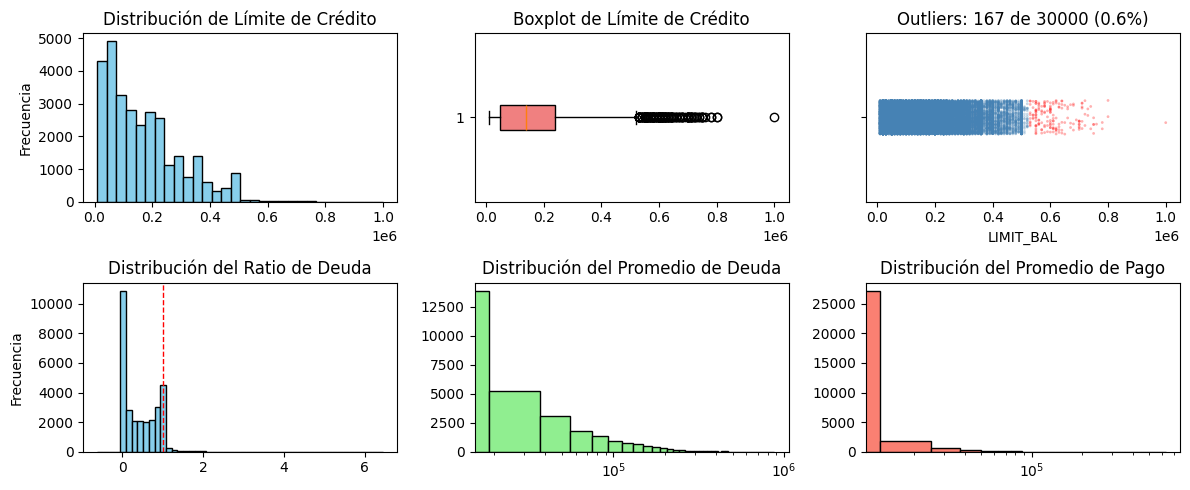

In [10]:
num_cols = ['LIMIT_BAL', 'AGE', 
            'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
            'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'] 

# Cálculo del IQR para detectar outliers en LIMIT_BAL
Q1 = df['LIMIT_BAL'].quantile(0.25)
Q3 = df['LIMIT_BAL'].quantile(0.75)
IQR = Q3 - Q1
filtro = (df['LIMIT_BAL'] >= Q1 - 1.5 * IQR) & (df['LIMIT_BAL'] <= Q3 + 1.5 * IQR)
outliers = df[~filtro]
df['es_outlier'] = ~filtro  # True = outlier

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(12, 5))

# 1️⃣ Distribución de variables → histogramas
ax1.hist(
    df['LIMIT_BAL'], bins=30, color='skyblue', 
    edgecolor='black')
ax1.set_title('Distribución de Límite de Crédito')
ax1.set_ylabel('Frecuencia')

# 2️⃣ Detección de outliers → boxplot
ax2.boxplot(
    df['LIMIT_BAL'], vert=False, patch_artist=True, 
    boxprops=dict(facecolor='lightcoral'))
ax2.set_title('Boxplot de Límite de Crédito')

# 3️⃣ Visualización con stripplot → outliers
sns.stripplot(
    x='LIMIT_BAL', data=df,
    hue='es_outlier', palette={True: 'red', False: 'steelblue'},
    alpha=0.3, size=2, ax=ax3,
    legend=False)
ax3.set_title(f'Outliers: {outliers.shape[0]} de {len(df)} ({outliers.shape[0]/len(df)*100:.1f}%)')

# 4️⃣ Histograma de Ratio de Deuda
ax4.hist(df['deb_ratio'], bins=50, color='skyblue', edgecolor='black')
ax4.set_title('Distribución del Ratio de Deuda')
ax4.set_ylabel('Frecuencia')
ax4.axvline(1.0, color='red', linestyle='dashed', 
    linewidth=1, label='umbral en 1.0')

# 5️⃣ Histograma de Promedio de Deuda
ax5.hist(df['avg_bill'], bins=50, color='lightgreen', edgecolor='black')
ax5.set_title('Distribución del Promedio de Deuda')
ax5.set_xscale('log')  # Escala logarítmica para mejor visualización

# 6️⃣ Histograma de Promedio de Pago
ax6.hist(df['avg_pay'], bins=50, color='salmon', edgecolor='black')
ax6.set_title('Distribución del Promedio de Pago')
ax6.set_xscale('log')  # Escala logarítmica para mejor visualización

plt.tight_layout()
plt.show()


### Univariado categórico/ordinal
> SEX, EDUCATION, MARRIAGE, PAY_0...PAY_6 

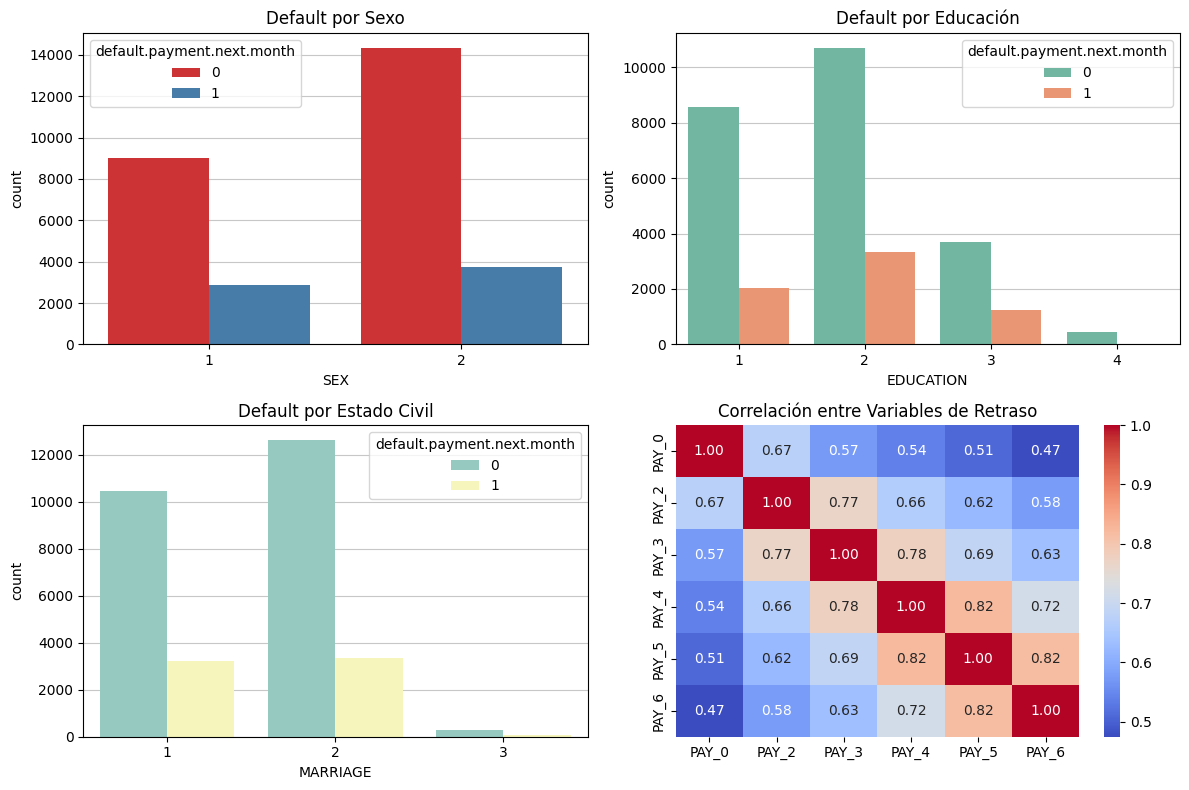

            SEX  EDUCATION  MARRIAGE  num_delays
count  30000.00   30000.00  30000.00    30000.00
mean       1.60       1.84      1.56        0.83
std        0.49       0.74      0.52        1.55
min        1.00       1.00      1.00        0.00
25%        1.00       1.00      1.00        0.00
50%        2.00       2.00      2.00        0.00
75%        2.00       2.00      2.00        1.00
max        2.00       4.00      3.00        6.00


In [11]:
# Visualización de la distribución de variables categóricas
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12,8))

# 1️⃣ Grafico de barras para SEX
sns.countplot(
    x='SEX', hue='default.payment.next.month', 
    data=df, ax=ax1, palette='Set1')
ax1.set_title('Default por Sexo')
ax1.yaxis.grid(True, alpha=0.7)  # Agregar cuadrícula al eje y del primer subplot
ax1.set_axisbelow(True)  # Asegurarse de que la cuadrícula esté detrás de las barras

# 2️⃣ Grafico de barras para EDUCATION
sns.countplot(
    x='EDUCATION', hue='default.payment.next.month', 
    data=df, ax=ax2, palette='Set2')
ax2.set_title('Default por Educación')
ax2.yaxis.grid(True, alpha=0.7)
ax2.set_axisbelow(True)

# 3️⃣ Grafico de barras para MARRIAGE
sns.countplot(
    x='MARRIAGE', hue='default.payment.next.month', 
    data=df, ax=ax3, palette='Set3')
ax3.set_title('Default por Estado Civil')
ax3.yaxis.grid(True, alpha=0.7)
ax3.set_axisbelow(True)

# 4️⃣ Heatmap de correlación entre variables de retraso
# Si alguien se atrasa este mes, probablemente también el siguiente.
sns.heatmap(
    df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].corr(), 
    annot=True, fmt=".2f", cmap='coolwarm', ax=ax4)
ax4.set_title('Correlación entre Variables de Retraso')
plt.tight_layout()
plt.show()

# Resumen estadístico de variables categóricas/ordinales
resumen = df[['SEX', 'EDUCATION', 'MARRIAGE', 'num_delays']].describe().round(2)
print(resumen)


### Relación con el target / multivariado
> countplots con hue, heatmap de correlación, pairplot, 
scatter, PCA/UMAP

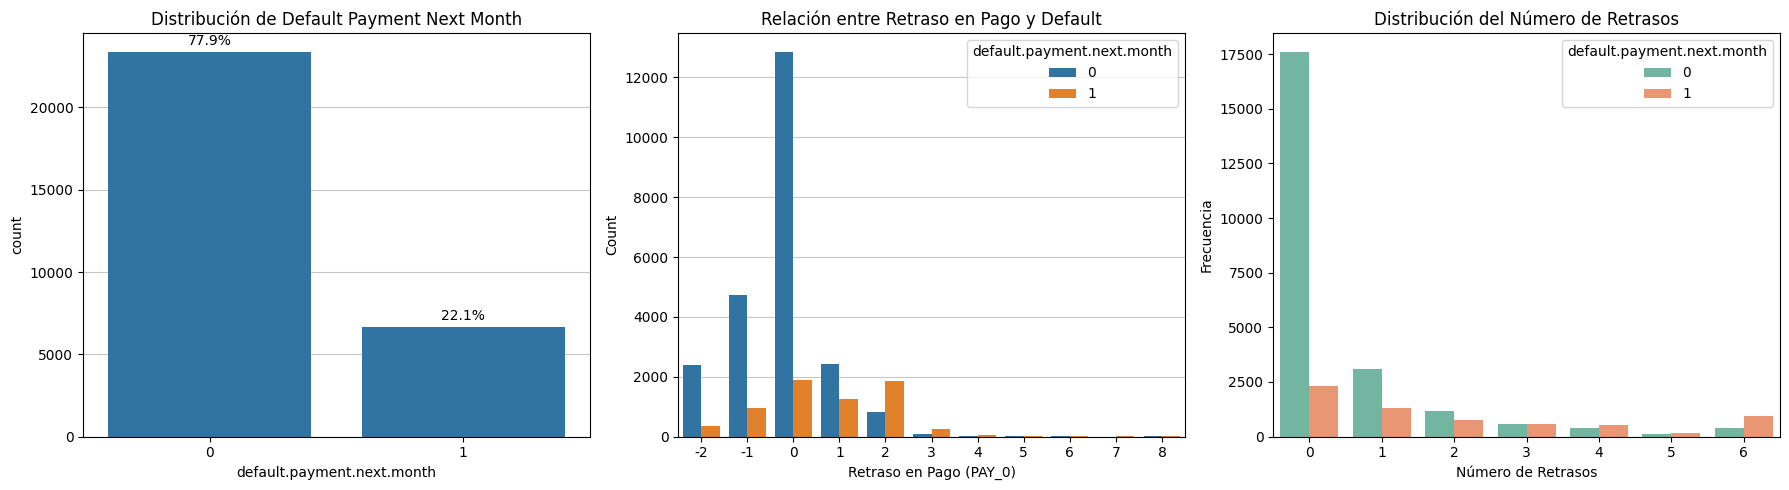

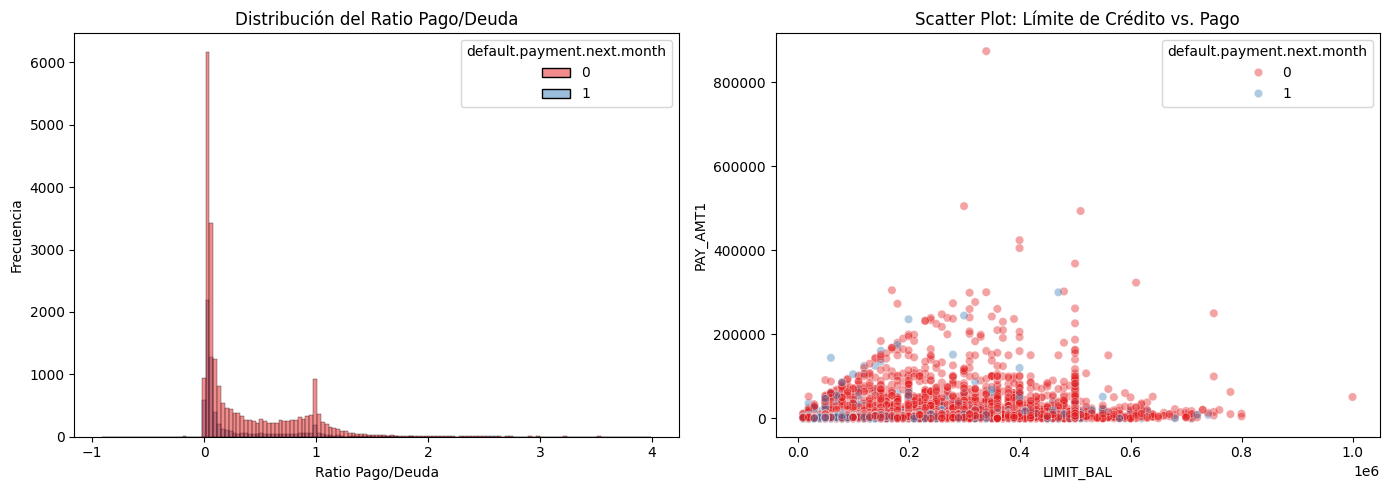

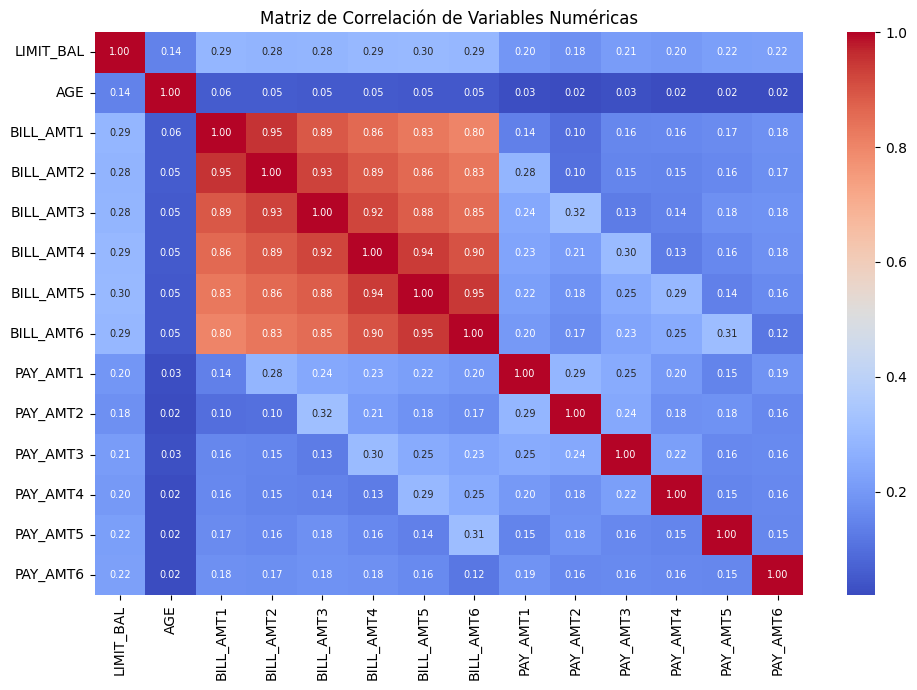

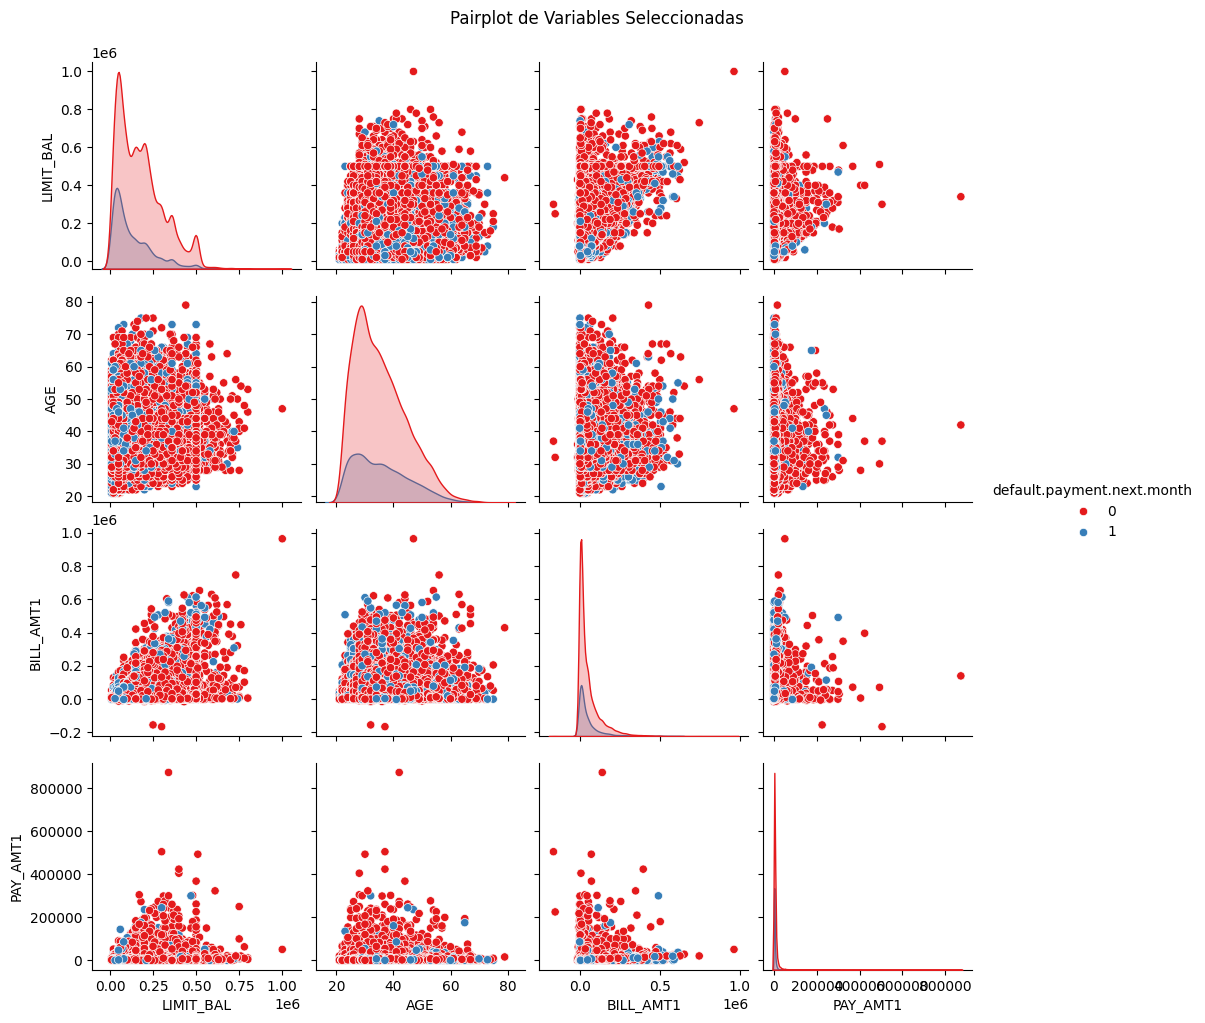

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1️⃣ Distribución de la variable objetivo (primero: da el contexto de balance de clases)
sns.countplot(x='default.payment.next.month', data=df, ax=ax1)
total = len(df)
for container in ax1.containers:
    ax1.bar_label(container, 
        labels=[f'{v/total*100:.1f}%' for v in container.datavalues],
        padding=3, fontsize=10, color='black')
ax1.set_title('Distribución de Default Payment Next Month')
ax1.yaxis.grid(True, alpha=0.7)
ax1.set_axisbelow(True)

# 2️⃣ Comportamiento de retrasos vs. default
sns.countplot(
    x='PAY_0', hue='default.payment.next.month', data=df, ax=ax2)
ax2.set_title('Relación entre Retraso en Pago y Default')
ax2.set_xlabel('Retraso en Pago (PAY_0)')
ax2.set_ylabel('Count')
ax2.yaxis.grid(True, alpha=0.7)
ax2.set_axisbelow(True)

# 3️⃣ Ratios y relaciones deuda/pago vs. default
sns.countplot(
    x='num_delays', hue='default.payment.next.month', 
    data=df, palette='Set2', ax=ax3)
ax3.set_title('Distribución del Número de Retrasos')
ax3.set_xlabel('Número de Retrasos')
ax3.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 4️⃣ Distribución del ratio de pago a deuda
sns.histplot(
    x='pay_to_bill_ratio', hue='default.payment.next.month',
    data=df[(df['pay_to_bill_ratio'] > -1) 
            & (df['pay_to_bill_ratio'] < 4)],   # filtra outliers
    palette='Set1', alpha=0.5, ax=ax1)
ax1.set_title('Distribución del Ratio Pago/Deuda')
ax1.set_xlabel('Ratio Pago/Deuda')
ax1.set_ylabel('Frecuencia')

# 5️⃣ Relación entre límite de crédito y pago
sns.scatterplot(
    x='LIMIT_BAL', y='PAY_AMT1', hue='default.payment.next.month',
    data=df, ax=ax2, palette='Set1', alpha=0.4)
ax2.set_title('Scatter Plot: Límite de Crédito vs. Pago')
plt.tight_layout()
plt.show()

# 6️⃣ Matriz de correlación de variables numéricas (LIMIT_BAL, BILL_AMT*, PAY_AMT*)
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[num_cols].corr(), annot=True, fmt=".2f", 
    cmap='coolwarm', annot_kws={"size": 7})
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

# 7️⃣ Relación multivariada → pairplot
rel_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1'] 
sns.pairplot(
    df[rel_cols + ['default.payment.next.month']], 
    hue='default.payment.next.month',
    palette='Set1', diag_kind='kde')
plt.suptitle('Pairplot de Variables Seleccionadas', y=1.02)
plt.show()


In [13]:
# Columnas
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month',
 'deb_ratio',
 'avg_bill',
 'avg_pay',
 'pay_to_bill_ratio',
 'num_delays',
 'es_outlier']

## 6. Split

In [14]:
# ---- Clasificación ----
X_class = df.drop(columns=
    ['ID', 'default.payment.next.month', 'es_outlier', 'avg_bill', 
    'avg_pay', 'deb_ratio', 'num_delays'])
y_class = df['default.payment.next.month']

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)

# ---- Regresión ----
X_reg = df.drop(columns=
    ['ID', 'default.payment.next.month', 'es_outlier', 'LIMIT_BAL', 
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 
    'BILL_AMT6', 'deb_ratio', 'pay_to_bill_ratio', 'avg_bill'])
y_reg1 = df['avg_bill']
y_reg2 = df['LIMIT_BAL']

X_train_reg, X_test_reg = train_test_split(
    X_reg, test_size=0.2, random_state=42)
y_train_reg1, y_test_reg1 = y_reg1.loc[
    X_train_reg.index], y_reg1.loc[X_test_reg.index]
y_train_reg2, y_test_reg2 = y_reg2.loc[
    X_train_reg.index], y_reg2.loc[X_test_reg.index]

# ---- Clustering (sin target) ----
cat_cluster_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
                    
X_cluster = df.drop(columns=
    ['ID', 'default.payment.next.month', 'es_outlier']) # codificar SEX, EDUCATION, MARRIAGE
X_train_cluster, X_test_cluster = train_test_split(
    X_cluster, test_size=0.2, random_state=42)

# ---- Codificación (después del split, ajustada solo con train) ----
encoder = OneHotEncoder(
    handle_unknown='ignore', sparse_output=False)  # Sin drop='first'
train_encoded = encoder.fit_transform(X_train_cluster[cat_cluster_cols])
test_encoded = encoder.transform(X_test_cluster[cat_cluster_cols])

encoder_cols = encoder.get_feature_names_out(cat_cluster_cols)  # Nombres de las columnas codificadas
train_encoded_df = pd.DataFrame(
    train_encoded, columns=encoder_cols, index=X_train_cluster.index)
test_encoded_df = pd.DataFrame(
    test_encoded, columns=encoder_cols, index=X_test_cluster.index)

X_train_cluster = pd.concat(
    [X_train_cluster.drop(columns=cat_cluster_cols), train_encoded_df], axis=1)
X_test_cluster = pd.concat(
    [X_test_cluster.drop(columns=cat_cluster_cols), test_encoded_df], axis=1)

print(f"Clustering -> Train: {X_train_cluster.shape} | Test: {X_test_cluster.shape}")


Clustering -> Train: (24000, 34) | Test: (6000, 34)


## 7. Escalado

In [15]:
# ==== Clasificación ====
n_cols_class = [
    'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
    'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 
    'pay_to_bill_ratio']  # Columnas numéricas para escalado
categoricas = [
    'SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 
    'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']  # Columnas categóricas para codificación

# Copiamos los datos para no modificar los originales
X_train_class_scaled = X_train_class.copy()
X_test_class_scaled = X_test_class.copy()
X_train_class_R = X_train_class.copy()
X_test_class_R = X_test_class.copy()

scaler_S_class = StandardScaler()
X_train_class_scaled[n_cols_class] = scaler_S_class.fit_transform(
    X_train_class[n_cols_class])
X_test_class_scaled[n_cols_class] = scaler_S_class.transform(
    X_test_class[n_cols_class])

scaler_R_class = RobustScaler()
X_train_class_R[n_cols_class] = scaler_R_class.fit_transform(
    X_train_class[n_cols_class])
X_test_class_R[n_cols_class] = scaler_R_class.transform(
    X_test_class[n_cols_class])

print(f"Clasificación -> Standard: {X_train_class_scaled.shape} | Robust: {X_train_class_R.shape}")

# ==== Regresión ====
n_cols_reg = [
    'AGE', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 
    'PAY_AMT5', 'PAY_AMT6', 'avg_pay', 'num_delays'
    ]  # Columnas numéricas para escalado

# Copiamos los datos para no modificar los originales
X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()
X_train_reg_R = X_train_reg.copy()
X_test_reg_R = X_test_reg.copy()

scaler_S_reg = StandardScaler()
X_train_reg_scaled[n_cols_reg] = scaler_S_reg.fit_transform(
    X_train_reg[n_cols_reg])
X_test_reg_scaled[n_cols_reg] = scaler_S_reg.transform(
    X_test_reg[n_cols_reg])

scaler_R_reg = RobustScaler()
X_train_reg_R[n_cols_reg] = scaler_R_reg.fit_transform(
    X_train_reg[n_cols_reg])
X_test_reg_R[n_cols_reg] = scaler_R_reg.transform(
    X_test_reg[n_cols_reg])

print(f"Regresión -> Standard: {X_train_reg_scaled.shape} | Robust: {X_train_reg_R.shape}")

# ==== Clustering ====
n_cols_cluster = [
    'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 
    'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 
    'deb_ratio', 'avg_bill', 'avg_pay', 'pay_to_bill_ratio',
    'num_delays'] # Se deja fuera PAY_0-6 (ordinales) y las dummies 0/1 del one-hot encoding

# Copias sin escalar, para interpretar los clusters en $ reales, no en unidades escaladas
X_train_cluster_raw = X_train_cluster.copy()
X_test_cluster_raw = X_test_cluster.copy()

scaler_R_cluster = RobustScaler()
X_train_cluster[n_cols_cluster] = scaler_R_cluster.fit_transform(
    X_train_cluster[n_cols_cluster])
X_test_cluster[n_cols_cluster] = scaler_R_cluster.transform(
    X_test_cluster[n_cols_cluster])

print(f"Clustering -> Train: {X_train_cluster.shape} | Test: {X_test_cluster.shape}")

Clasificación -> Standard: (24000, 24) | Robust: (24000, 24)
Regresión -> Standard: (24000, 18) | Robust: (24000, 18)
Clustering -> Train: (24000, 34) | Test: (6000, 34)


## 8. Reducción de Dimensionalidad (Opcional)

Primero escalas, luego reduces dimensión.
Nunca al revés.

PCA DEBE hacerse con datos escalados, porque PCA es sensible a escala. (X_train_scaled)

Clasificación (Standard): varianza explicada [0.4  0.12 0.07 0.07 0.06 0.06 0.05 0.05 0.05] | varianza acumulada [0.4  0.51 0.58 0.65 0.71 0.77 0.83 0.88 0.93]
Clasificación (Robust): varianza explicada [1. 0. 0. 0. 0. 0. 0. 0. 0.] | varianza acumulada [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Regresión (Standard): varianza explicada [0.33 0.11 0.11 0.1  0.1  0.09 0.08 0.08 0.  ] | varianza acumulada [0.33 0.45 0.55 0.65 0.75 0.84 0.92 1.   1.  ]
Regresión (Robust): varianza explicada [0.38 0.16 0.12 0.11 0.11 0.1  0.02 0.   0.  ] | varianza acumulada [0.38 0.54 0.66 0.77 0.88 0.98 1.   1.   1.  ]


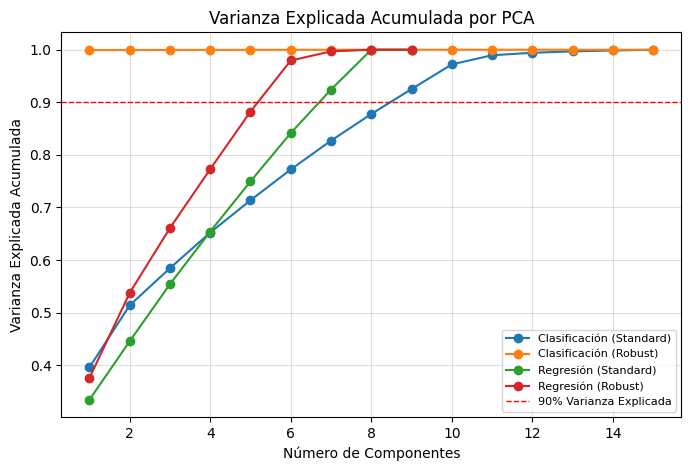

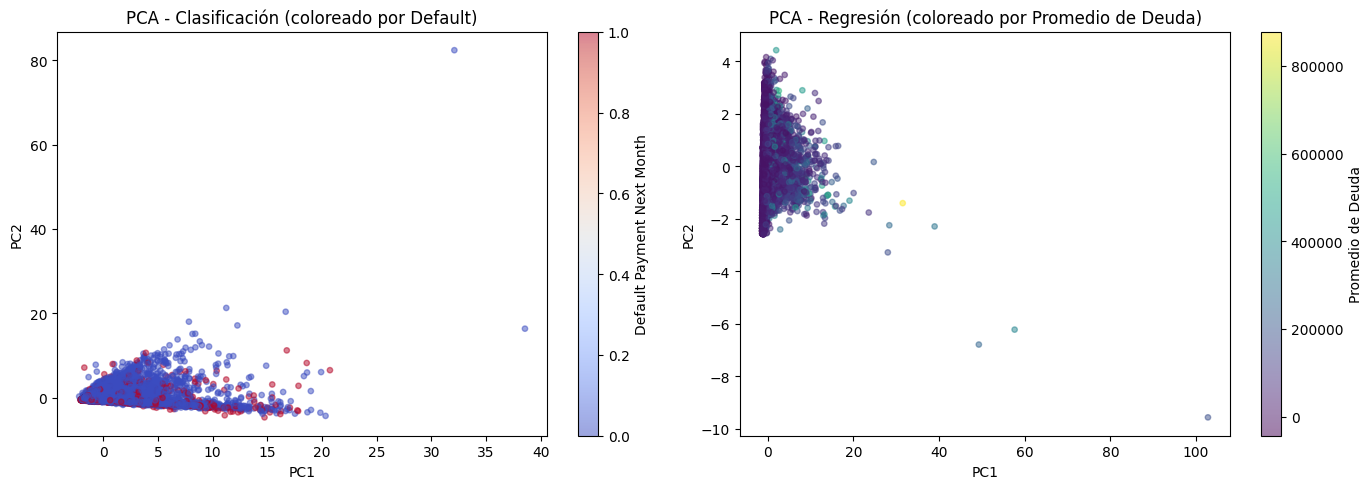

In [16]:
# PCA para reducción de dimensionalidad a 2D en clasificacion y regresión 
# ya que se basa en varianza lineal

def aplicar_pca(X_train, X_test, cols, n_components=9):
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train[cols])
    X_test_pca = pca.transform(X_test[cols])
    return X_train_pca, X_test_pca, pca

variantes_pca = {
    'Clasificación (Standard)': (X_train_class_scaled, X_test_class_scaled, n_cols_class),
    'Clasificación (Robust)': (X_train_class_R, X_test_class_R, n_cols_class),
    'Regresión (Standard)': (X_train_reg_scaled, X_test_reg_scaled, n_cols_reg),
    'Regresión (Robust)': (X_train_reg_R, X_test_reg_R, n_cols_reg)
}

resultados_pca = {}
for nombre, (X_train, X_test, cols) in variantes_pca.items():
    Xtr_pca, Xte_pca, pca_obj = aplicar_pca(X_train, X_test, cols)
    resultados_pca[nombre] = {'train': Xtr_pca, 'test': Xte_pca, 'pca': pca_obj}
    var_exp = pca_obj.explained_variance_ratio_
    var_acum = var_exp.cumsum()
    print(f"{nombre}: varianza explicada {var_exp.round(2)} | varianza acumulada {var_acum.round(2)}")

# Gráfica de varianza explicada acumulada para PCA
plt.figure(figsize=(8, 5))
for nombre, (Xtr, Xte, cols) in variantes_pca.items():
    var_acum = PCA().fit(Xtr[cols]).explained_variance_ratio_.cumsum()
    plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o', label=nombre)

plt.axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% Varianza Explicada')
plt.title('Varianza Explicada Acumulada por PCA')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.4)
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sc1 = ax1.scatter(
    resultados_pca['Clasificación (Standard)']['train'][:, 0], 
    resultados_pca['Clasificación (Standard)']['train'][:, 1], 
    c=y_train_class, cmap='coolwarm', alpha=0.5, s=15)
ax1.set_title('PCA - Clasificación (coloreado por Default)')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
plt.colorbar(sc1, ax=ax1, label='Default Payment Next Month')

sc2 = ax2.scatter(
    resultados_pca['Regresión (Standard)']['train'][:, 0], 
    resultados_pca['Regresión (Standard)']['train'][:, 1], 
    c=y_train_reg1, cmap='viridis', alpha=0.5, s=15)
ax2.set_title('PCA - Regresión (coloreado por Promedio de Deuda)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
plt.colorbar(sc2, ax=ax2, label='Promedio de Deuda')

plt.tight_layout()
plt.show()


Curva de varianza acumulada: Las versiones Standard (azul y verde) son las que tienen sentido ya que necesitan entre 9 y 10 componentes para llegar al 90% de varianza. El feature engineering creó varias señales bastante independientes entre sí (comportamiento de pago, deuda, demografía), así que no debería comprimirse en 2 componentes fácilmente.

Las versiones Robust (naranja y roja) están rotas, no son un buen resultado. Que PC1 explique 100% ([1. 0.]) en clasificación-Robust es una señal de alarma, no de éxito, significa que casi toda la "varianza" que ve PCA proviene de un puñado de valores extremos, no de estructura real de los datos. Esto pasa porque RobustScaler divide entre el IQR (rango intercuartílico), que es mucho más pequeño que la desviación estándar, así que cuando SÍ hay un valor verdaderamente extremo, Robust no lo recorta, solo cambia la referencia de centrado/escala, y ese punto termina con un z-score todavía más descomunal que con Standard.

c:\Users\JanBA\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Datos reducidos con UMAP:


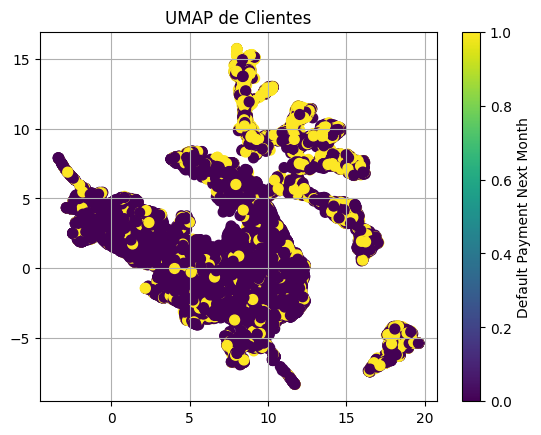

In [17]:
# UMAP para reducción de dimensionalidad a 2D en clustering 
# ya que se basa en distancias y puede capturar relaciones no lineales
y_cluster_train = df['default.payment.next.month'].loc[X_train_cluster.index]

reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_train_cluster[n_cols_cluster])

print("Datos reducidos con UMAP:")
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_cluster_train, cmap='viridis', s=50)
plt.colorbar(label='Default Payment Next Month')
plt.title('UMAP de Clientes')
plt.grid(True)
plt.show()


Este gráfico sí encuentra formas y estructura reales. El color amarillo (default=1) está disperso por toda la figura, mezclado con el morado, sin que haya una región donde domine claramente uno u otro. Esto indica que los segmentos naturales que encuentra UMAP (probablemente por patrones de gasto/límite de crédito) no corresponden directamente a riesgo de default, hay clientes que caen en default en prácticamente todos los "tipos" de cliente, no solo en un segmento aislado, la segmentación sirve para entender tipos de comportamiento financiero, pero no reemplaza al modelo de clasificación para predecir riesgo.

## 9. Clasificación

### Modelo Clasificación

**Logistic Regression:** relaciones lineales, sensible a outliers, sensible a escala, no robusto a multicolinealidad\
**Random Forest Classifier:** Basado en árboles, insensible a escala, relaciones no lineales, robusto a outliers\
**KNeighbors Classifier:** Basado en distancia, sensible a escala, relaciones no lineales, sensible a outliers

In [18]:
#---------- Modelos predictivos para clasificación
modelos_class = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=15)
}

# --------- Variantes de datasets para clasificación
datasets_class = {
    'Simple':   (X_train_class,         X_test_class),
    'Standard': (X_train_class_scaled,  X_test_class_scaled),
    'Robust':   (X_train_class_R,       X_test_class_R),
    'PCA':      (resultados_pca['Clasificación (Standard)']['train'], 
                 resultados_pca['Clasificación (Standard)']['test'])
}

# --------- Resultados de modelos de clasificación
resultados_class = {}

for var_nombre, (Xtr, Xte) in datasets_class.items():
    for mod_nombre, modelo in modelos_class.items():
        modelo_ajustado = clone(modelo)             # Copia sin ajustar, evita pisar el fit anterior
        modelo_ajustado.fit(Xtr, y_train_class)
        y_pred = modelo_ajustado.predict(Xte)
        y_prob = modelo_ajustado.predict_proba(Xte)[:, 1]  # para ROC-AUC más adelante

        acc = accuracy_score(y_test_class, y_pred)
        resultados_class[(var_nombre, mod_nombre)] = {
            'modelo': modelo_ajustado, 
            'y_pred': y_pred, 'y_prob': y_prob, 'accuracy': acc
        }
        print(f"{var_nombre:9s} - {mod_nombre:18s} -> Accuracy = {acc:.4f}")


c:\Users\JanBA\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Simple    - LogisticRegression -> Accuracy = 0.6112
Simple    - RandomForest       -> Accuracy = 0.8130
Simple    - KNN                -> Accuracy = 0.7733
Standard  - LogisticRegression -> Accuracy = 0.6800
Standard  - RandomForest       -> Accuracy = 0.8135
Standard  - KNN                -> Accuracy = 0.8127
Robust    - LogisticRegression -> Accuracy = 0.6797
Robust    - RandomForest       -> Accuracy = 0.8128
Robust    - KNN                -> Accuracy = 0.8123
PCA       - LogisticRegression -> Accuracy = 0.5082
PCA       - RandomForest       -> Accuracy = 0.7777
PCA       - KNN                -> Accuracy = 0.7783


### Evaluación Clasificación

In [19]:
filas = []
for (var_nombre, mod_nombre), res in resultados_class.items():
    filas.append({
        'Variante': var_nombre,
        'Modelo': mod_nombre,
        'Accuracy': res['accuracy'],
        'Precision (default)': precision_score(y_test_class, res['y_pred'], pos_label=1),
        'Recall (default)': recall_score(y_test_class, res['y_pred'], pos_label=1),
        'F1-Score (default)': f1_score(y_test_class, res['y_pred'], pos_label=1),
        'ROC-AUC': roc_auc_score(y_test_class, res['y_prob'])
    })
tabla_class = pd.DataFrame(filas).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
tabla_class.round(3)

,Variante,Modelo,Accuracy,Precision (default),Recall (default),F1-Score (default),ROC-AUC
0,Standard,RandomForest,0.814,0.649,0.341,0.447,0.760
1,Simple,RandomForest,0.813,0.647,0.340,0.446,0.759
2,Robust,RandomForest,0.813,0.647,0.339,0.445,0.758
3,Robust,KNN,0.812,0.642,0.342,0.446,0.739
4,Standard,KNN,0.813,0.638,0.354,0.455,0.734
5,Robust,LogisticRegression,0.680,0.367,0.619,0.461,0.708
6,Standard,LogisticRegression,0.680,0.367,0.619,0.461,0.708
7,Simple,LogisticRegression,0.611,0.318,0.665,0.431,0.689
8,PCA,RandomForest,0.778,0.484,0.080,0.137,0.658
9,Simple,KNN,0.773,0.451,0.115,0.183,0.646


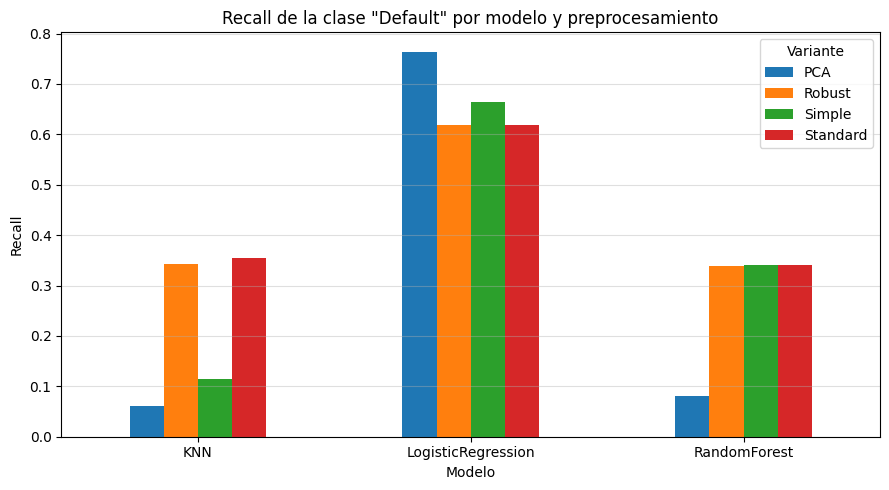

C:\Users\JanBA\AppData\Local\Temp\ipykernel_15140\771671116.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1], 'k--', lw=1, color='gray')
C:\Users\JanBA\AppData\Local\Temp\ipykernel_15140\771671116.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1], 'k--', lw=1, color='gray')
C:\Users\JanBA\AppData\Local\Temp\ipykernel_15140\771671116.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1], 'k--', lw=1, color='gray')


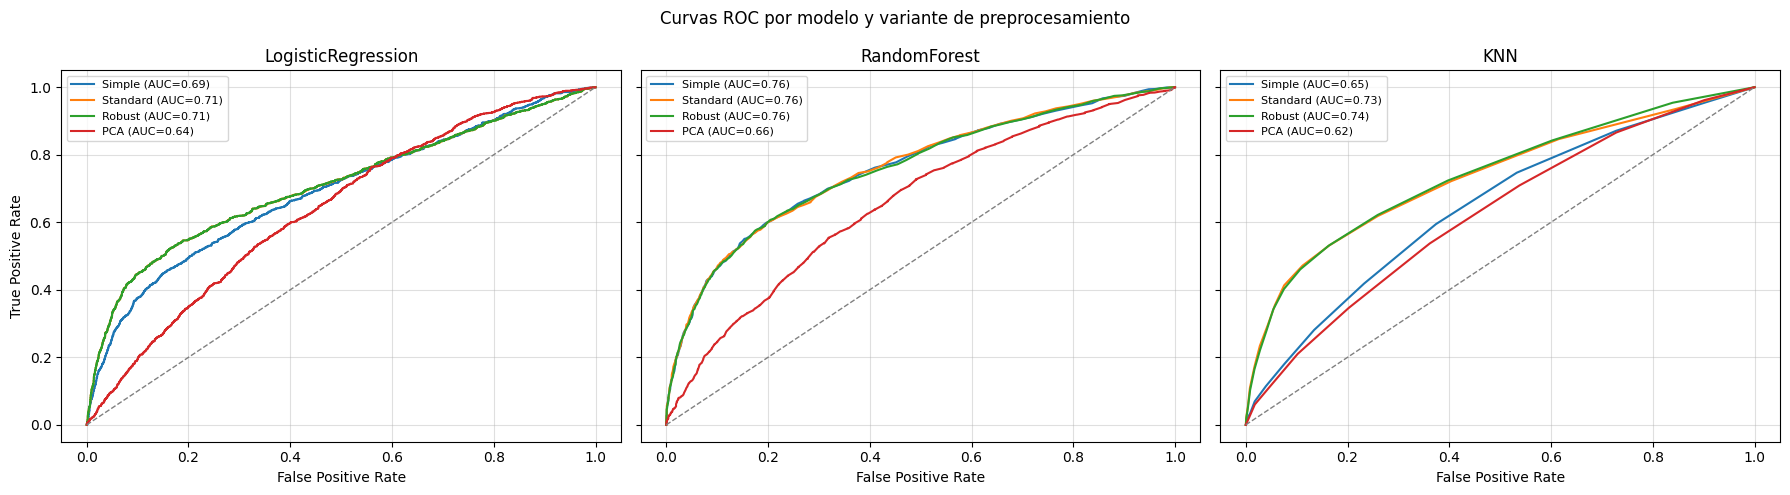

In [20]:
pivot_recall = tabla_class.pivot(
    index='Modelo', columns='Variante', values='Recall (default)')
pivot_recall.plot(kind='bar', figsize=(9, 5))
plt.title('Recall de la clase "Default" por modelo y preprocesamiento')
plt.ylabel('Recall')
plt.xticks(rotation=0)
plt.legend(title='Variante')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, mod_nombre in zip(axes, modelos_class.keys()):
    for var_nombre in datasets_class.keys():
        res = resultados_class[(var_nombre, mod_nombre)]
        fpr, tpr, _ = roc_curve(y_test_class, res['y_prob'])
        auc_val = roc_auc_score(y_test_class, res['y_prob'])
        ax.plot(fpr, tpr, label=f"{var_nombre} (AUC={auc_val:.2f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1, color='gray')
    ax.set_title(mod_nombre)
    ax.set_xlabel('False Positive Rate')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)

axes[0].set_ylabel('True Positive Rate')
plt.suptitle('Curvas ROC por modelo y variante de preprocesamiento')
plt.tight_layout()
plt.show()


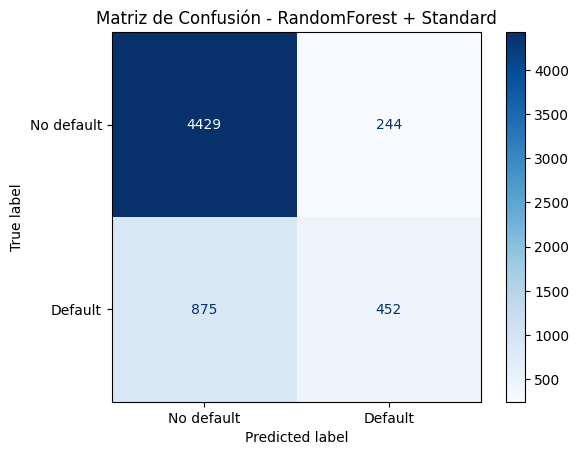

              precision    recall  f1-score   support

  No default       0.84      0.95      0.89      4673
     Default       0.65      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000



In [21]:
mejor = tabla_class.iloc[0]
mejor_res = resultados_class[(mejor['Variante'], mejor['Modelo'])]

ConfusionMatrixDisplay.from_predictions(
    y_test_class, mejor_res['y_pred'],
    display_labels=['No default', 'Default'], cmap='Blues')
plt.title(f"Matriz de Confusión - {mejor['Modelo']} + {mejor['Variante']}")
plt.show()

print(classification_report(
    y_test_class, mejor_res['y_pred'], 
    target_names=['No default', 'Default'])
    )

## 10. Regresión

### Modelo Regresión

In [22]:
#---------- Modelos predictivos para regresión
modelos_reg = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=15)
}

# --------- Variantes de datasets para regresión
datasets_reg = {
    'Simple':   (X_train_reg,         X_test_reg),
    'Standard': (X_train_reg_scaled,  X_test_reg_scaled),
    'Robust':   (X_train_reg_R,       X_test_reg_R),
    'PCA':      (resultados_pca['Regresión (Standard)']['train'], 
                 resultados_pca['Regresión (Standard)']['test'])
}

targets_reg = {
    'avg_bill': (y_train_reg1, y_test_reg1),
    'LIMIT_BAL': (y_train_reg2, y_test_reg2)
}

#---------- Resultados de modelos de regresión
resultados_reg = {}
for target_nombre, (y_tr, y_te) in targets_reg.items():
    for var_nombre, (Xtr, Xte) in datasets_reg.items():
        for mod_nombre, modelo in modelos_reg.items():
            modelo_ajustado = clone(modelo)
            modelo_ajustado.fit(Xtr, y_tr)
            y_pred = modelo_ajustado.predict(Xte)

            rmse = np.sqrt(mean_squared_error(y_te, y_pred))
            mae = mean_absolute_error(y_te, y_pred)
            r2 = r2_score(y_te, y_pred)

            resultados_reg[(target_nombre, var_nombre, mod_nombre)] = {
                'modelo': modelo_ajustado, 'y_pred': y_pred,
                'rmse': rmse, 'mae': mae, 'r2': r2
            }
            print(f"{target_nombre:9s} | {var_nombre:9s} | {mod_nombre:18s} -> "
                  f"RMSE: {rmse:,.0f} | MAE: {mae:,.0f}, R2: {r2:.3f}")


avg_bill  | Simple    | LinearRegression   -> RMSE: 53,723 | MAE: 35,274, R2: 0.302
avg_bill  | Simple    | RandomForest       -> RMSE: 23,210 | MAE: 10,850, R2: 0.870
avg_bill  | Simple    | KNN                -> RMSE: 41,498 | MAE: 22,399, R2: 0.584
avg_bill  | Standard  | LinearRegression   -> RMSE: 53,723 | MAE: 35,274, R2: 0.302
avg_bill  | Standard  | RandomForest       -> RMSE: 23,192 | MAE: 10,846, R2: 0.870
avg_bill  | Standard  | KNN                -> RMSE: 37,506 | MAE: 20,476, R2: 0.660
avg_bill  | Robust    | LinearRegression   -> RMSE: 53,723 | MAE: 35,274, R2: 0.302
avg_bill  | Robust    | RandomForest       -> RMSE: 23,206 | MAE: 10,849, R2: 0.870
avg_bill  | Robust    | KNN                -> RMSE: 34,356 | MAE: 17,397, R2: 0.715
avg_bill  | PCA       | LinearRegression   -> RMSE: 60,048 | MAE: 40,673, R2: 0.129
avg_bill  | PCA       | RandomForest       -> RMSE: 38,587 | MAE: 21,414, R2: 0.640
avg_bill  | PCA       | KNN                -> RMSE: 42,136 | MAE: 23,876, R2

### Evaluación Regresión

In [23]:
filas = []
for (target_nombre, var_nombre, mod_nombre), res in resultados_reg.items():
    filas.append({
        'Target': target_nombre,
        'Variante': var_nombre,
        'Modelo': mod_nombre,
        'RMSE': res['rmse'],
        'MAE': res['mae'],
        'R2': res['r2']
    })

tabla_reg = pd.DataFrame(filas).sort_values(
    ['Target', 'R2'], ascending=[True, False]).reset_index(drop=True)
tabla_reg.round(3)


,Target,Variante,Modelo,RMSE,MAE,R2
0,LIMIT_BAL,Standard,RandomForest,97727.433,71772.549,0.433
1,LIMIT_BAL,Simple,RandomForest,97752.503,71766.163,0.433
2,LIMIT_BAL,Robust,RandomForest,97756.002,71776.822,0.433
3,LIMIT_BAL,Robust,KNN,102099.634,74502.333,0.381
4,LIMIT_BAL,Standard,KNN,102400.576,76025.036,0.378
5,LIMIT_BAL,PCA,RandomForest,104863.793,78489.667,0.347
6,LIMIT_BAL,PCA,KNN,107194.997,79020.393,0.318
7,LIMIT_BAL,Simple,KNN,109783.695,82384.174,0.285
8,LIMIT_BAL,Robust,LinearRegression,111057.395,86546.720,0.268
9,LIMIT_BAL,Standard,LinearRegression,111057.395,86546.720,0.268


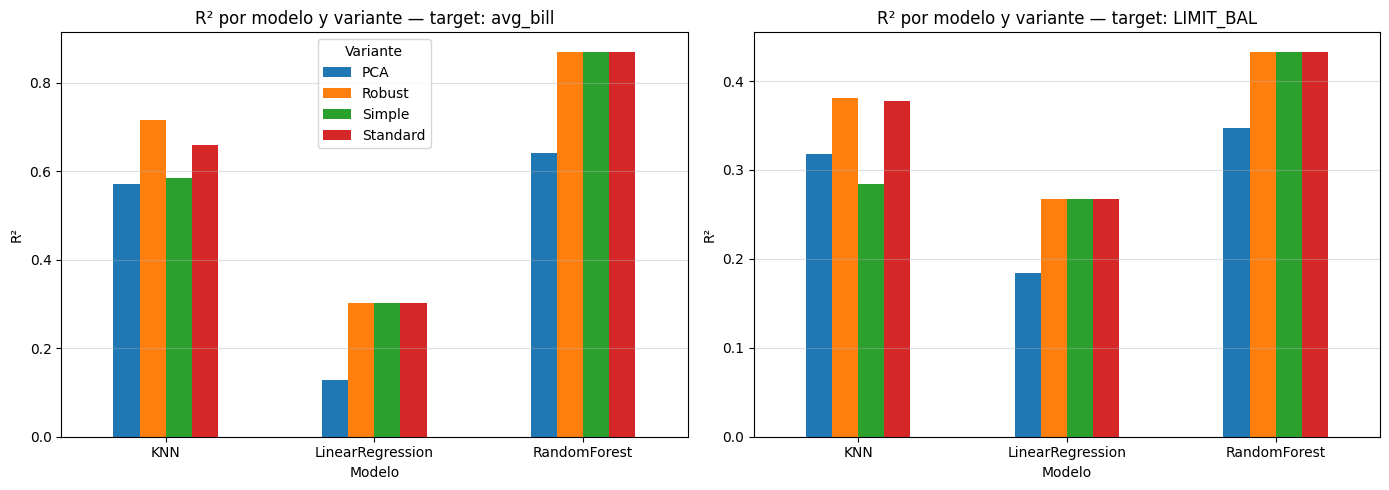

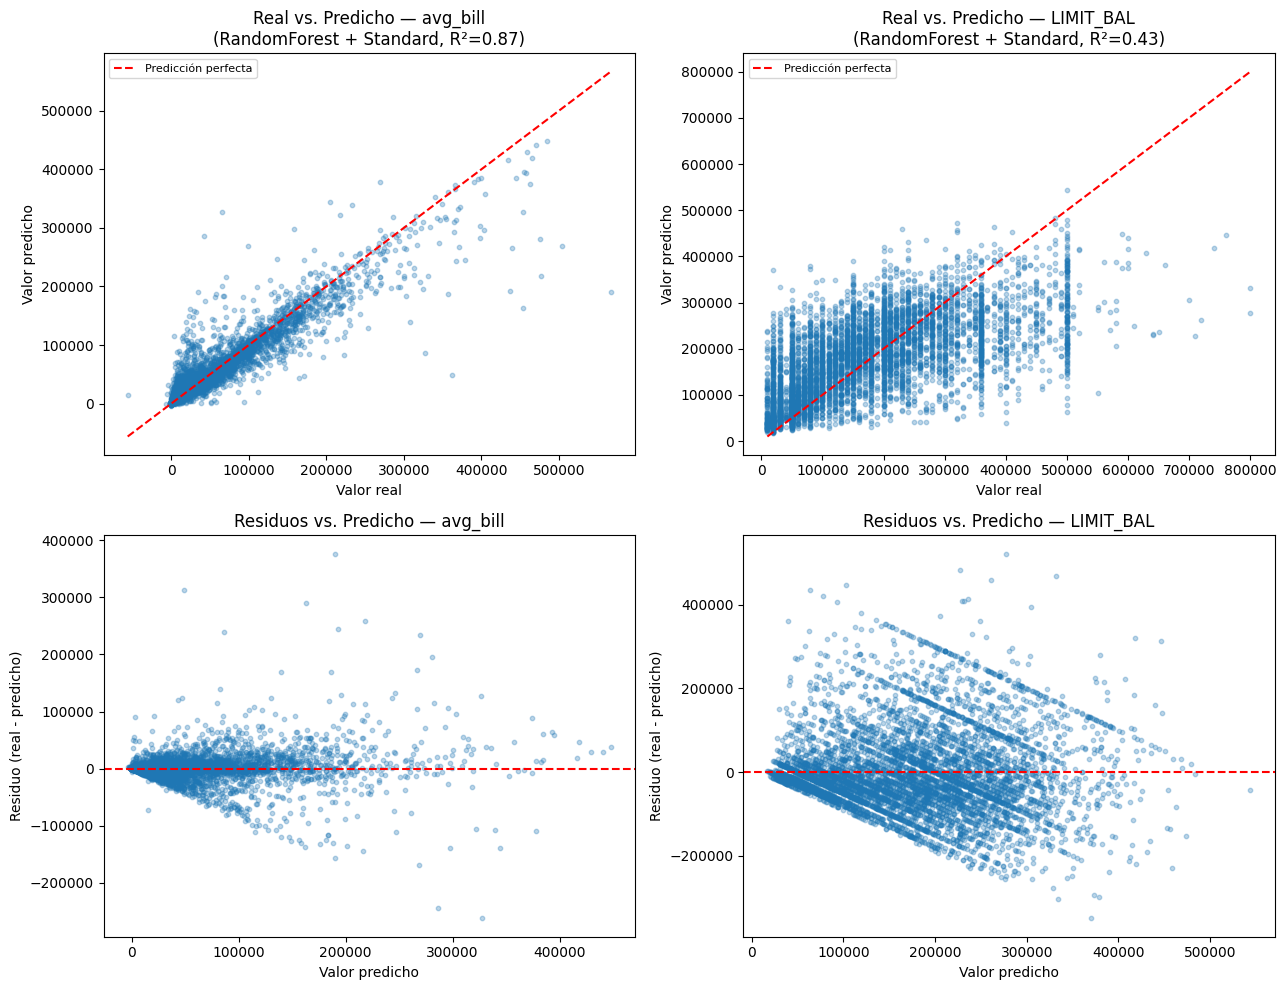

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target_nombre in zip(axes, targets_reg.keys()):
    subset = tabla_reg[tabla_reg['Target'] == target_nombre]
    pivot_r2 = subset.pivot(index='Modelo', columns='Variante', values='R2')
    pivot_r2.plot(kind='bar', ax=ax, legend=(target_nombre == 'avg_bill'))
    ax.set_title(f'R² por modelo y variante — target: {target_nombre}')
    ax.set_ylabel('R²'); ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col, target_nombre in enumerate(targets_reg.keys()):
    subset = tabla_reg[tabla_reg['Target'] == target_nombre].iloc[0]
    mejor_res = resultados_reg[(target_nombre, subset['Variante'], subset['Modelo'])]
    y_te = targets_reg[target_nombre][1]
    y_pred = mejor_res['y_pred']
    residuos = y_te - y_pred

    ax_scatter = axes[0, col]
    ax_scatter.scatter(y_te, y_pred, alpha=0.3, s=10)
    lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
    ax_scatter.plot(lims, lims, color='red', linestyle='--', label='Predicción perfecta')
    ax_scatter.set_title(f'Real vs. Predicho — {target_nombre}\n'
                         f'({subset["Modelo"]} + {subset["Variante"]}, R²={subset["R2"]:.2f})')
    ax_scatter.set_xlabel('Valor real'); ax_scatter.set_ylabel('Valor predicho')
    ax_scatter.legend(fontsize=8)

    ax_resid = axes[1, col]
    ax_resid.scatter(y_pred, residuos, alpha=0.3, s=10)
    ax_resid.axhline(0, color='red', linestyle='--')
    ax_resid.set_title(f'Residuos vs. Predicho — {target_nombre}')
    ax_resid.set_xlabel('Valor predicho'); ax_resid.set_ylabel('Residuo (real - predicho)')

plt.tight_layout()
plt.show()

## 11. Clustering

### Modelo Clustering

K=2, Silhouette Score: 0.39
K=3, Silhouette Score: 0.42
K=4, Silhouette Score: 0.39
K=5, Silhouette Score: 0.41
K=6, Silhouette Score: 0.42
K=7, Silhouette Score: 0.47
K=8, Silhouette Score: 0.44
K=9, Silhouette Score: 0.47
K=10, Silhouette Score: 0.47


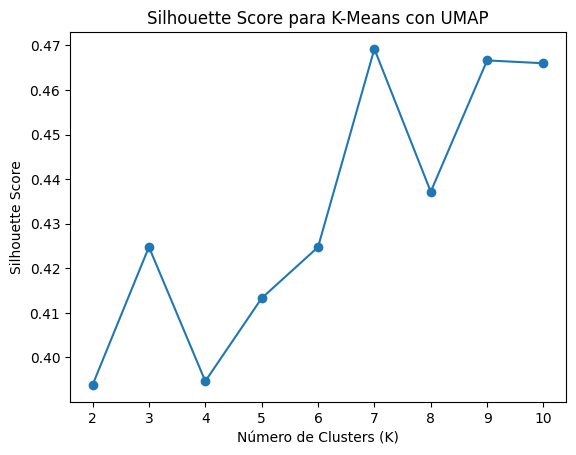

In [25]:
# Evaluar el mejor número de clusters con silhouette score
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_umap)
    score = silhouette_score(X_umap, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score: {score:.2f}")

plt.plot(range(2, 11), sil_scores, marker='o')
plt.title('Silhouette Score para K-Means con UMAP')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

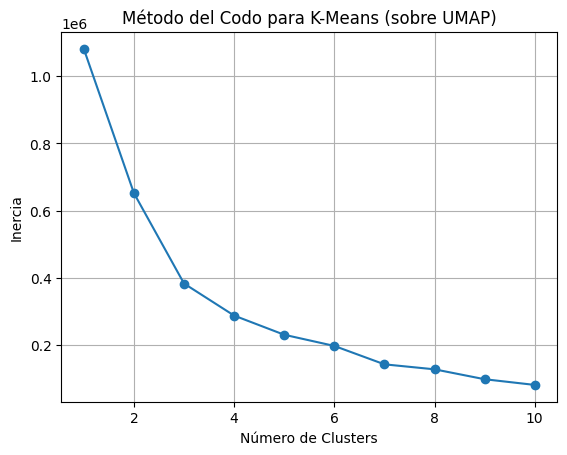

In [26]:
# Método Elbow Method para determinar el número óptimo de clusters en K-Means
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_umap)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del Codo para K-Means (sobre UMAP)')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

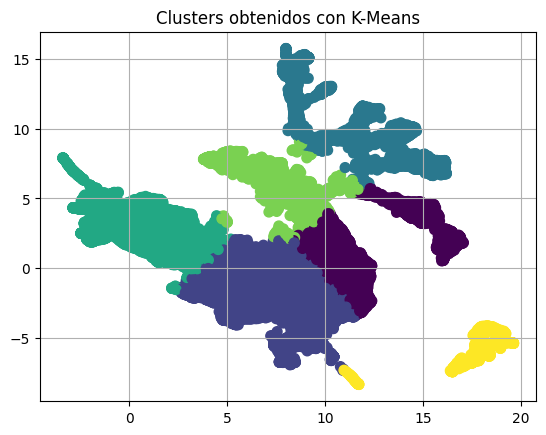

In [27]:
# ---- Modelo KMens ----

# Definir el número de clusters para K-Means
n_clusters = 6  # Basado en el análisis de silhouette score y elbow method
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Ajustar el modelo K-Means a los datos reducidos con UMAP
kmeans.fit(X_umap)

# Obtener las etiquetas de los clusters
labels_kmeans = kmeans.labels_

# Visualizar los clusters obtenidos con K-Means
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_kmeans, cmap='viridis', s=50)
plt.title('Clusters obtenidos con K-Means')
plt.grid(True)
plt.show() 


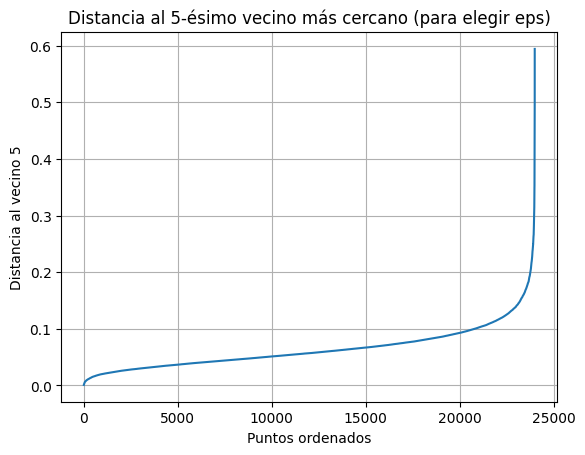

In [28]:
# Elegir eps de DBSCAN con un gráfico de distancia-k

min_samples = 5  # regla común: ~2 x n_dimensiones (aquí 2D -> 4-5 es razonable)
vecinos = NearestNeighbors(n_neighbors=min_samples).fit(X_umap)
distancias, _ = vecinos.kneighbors(X_umap)
distancias_k = np.sort(distancias[:, -1])

plt.plot(distancias_k)
plt.title(f'Distancia al {min_samples}-ésimo vecino más cercano (para elegir eps)')
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al vecino {min_samples}')
plt.grid(True); 
plt.show()

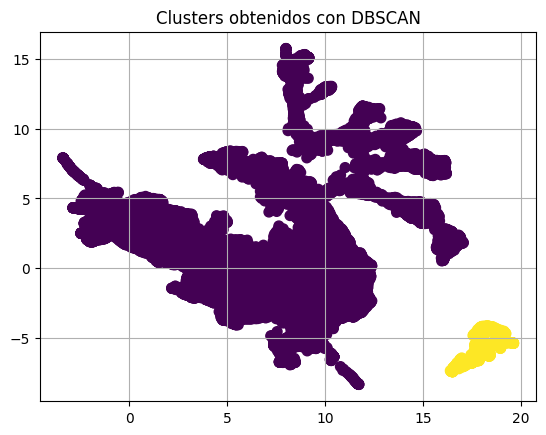

In [29]:
# ---- Modelo DBScan ----

# Definir los parámetros para DBSCAN
eps_elegido = 1.0
dbscan = DBSCAN(eps=eps_elegido, min_samples=min_samples)

# Ajustar el modelo DBSCAN a los datos reducidos con UMAP
dbscan.fit(X_umap)

# Obtener las etiquetas de los clusters
labels_dbscan = dbscan.labels_

# Visualizar los clusters obtenidos con DBSCAN
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_dbscan, cmap='viridis', s=50)
plt.title('Clusters obtenidos con DBSCAN')
plt.grid(True)
plt.show()


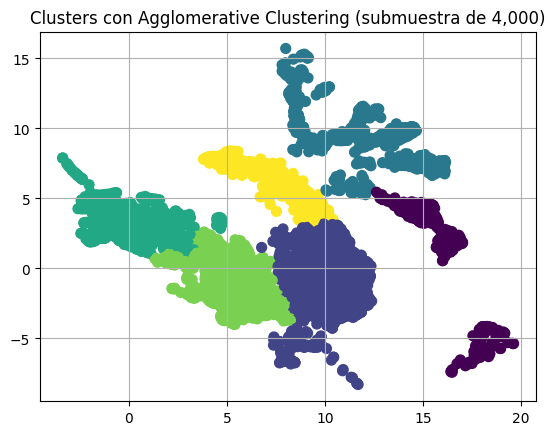

In [30]:
# ---- Modelo Agglomerative ----
#  Submuestra para Agglomerative, por el costo computacional
n_muestra = 4000

idx_muestra = np.random.RandomState(42).choice(
    len(X_umap), size=n_muestra, replace=False)
X_umap_muestra = X_umap[idx_muestra]

hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
labels_hierarchical = hierarchical.fit_predict(X_umap_muestra)

plt.scatter(
    X_umap_muestra[:, 0], X_umap_muestra[:, 1], 
    c=labels_hierarchical, cmap='viridis', s=50)
plt.title('Clusters con Agglomerative Clustering (submuestra de 4,000)')
plt.grid(True)
plt.show()

### Evaluación Clustering

In [31]:
# Silhouette
silhouette_kmeans = silhouette_score(X_umap, labels_kmeans)
print(f"Silhouette Score para K-Means: {silhouette_kmeans:.2f}")
# quitar ruido de DBSCAN (etiqueta -1)
mask_dbscan = labels_dbscan != -1
silhouette_dbscan = silhouette_score(
    X_umap[mask_dbscan], 
    labels_dbscan[mask_dbscan]
    )
print(f"Silhouette Score para DBSCAN: {silhouette_dbscan:.2f}")
silhouette_hierarchical = silhouette_score(X_umap_muestra, labels_hierarchical)
print(f"Silhouette Score para Agglomerative Clustering: {silhouette_hierarchical:.2f}")

# Davies-Bouldin Index
daviesB_kmeans = davies_bouldin_score(X_umap, labels_kmeans)
print(f"Davies-Bouldin Index para K-Means: {daviesB_kmeans:.2f}")
daviesB_dbscan = davies_bouldin_score(
    X_umap[mask_dbscan], labels_dbscan[mask_dbscan])
print(f"Davies-Bouldin Index para DBSCAN: {daviesB_dbscan:.2f}")
daviesB_hierarchical = davies_bouldin_score(X_umap_muestra, labels_hierarchical)
print(f"Davies-Bouldin Index para Agglomerative Clustering: {daviesB_hierarchical:.2f}")

# Calinski-Harabasz 
calinski_kmeans = calinski_harabasz_score(X_umap, labels_kmeans)
print(f"Calinski-Harabasz Index para K- Means: {calinski_kmeans:.2f}")
calinski_dbscan = calinski_harabasz_score(
    X_umap[mask_dbscan], labels_dbscan[mask_dbscan])
print(f"Calinski-Harabasz Index para DBSCAN: {calinski_dbscan:.2f}")
calinski_hierarchical = calinski_harabasz_score(X_umap_muestra, labels_hierarchical)
print(f"Calinski-Harabasz Index para Agglomerative Clustering: {calinski_hierarchical:.2f}")


Silhouette Score para K-Means: 0.42
Silhouette Score para DBSCAN: 0.38
Silhouette Score para Agglomerative Clustering: 0.43
Davies-Bouldin Index para K-Means: 0.78
Davies-Bouldin Index para DBSCAN: 0.55
Davies-Bouldin Index para Agglomerative Clustering: 0.84
Calinski-Harabasz Index para K- Means: 21534.46
Calinski-Harabasz Index para DBSCAN: 1870.84
Calinski-Harabasz Index para Agglomerative Clustering: 3803.19


In [32]:
# Evaluar si los clusters separan defaulters de no defaulters
# Si un cluster tiene muchos más defaults
# significa que el clustering está capturando riesgo crediticio.
y_muestra = y_cluster_train.iloc[idx_muestra]

KM = pd.crosstab(labels_kmeans, y_cluster_train)
print("Crosstab para K-Means:", KM)

DB = pd.crosstab(labels_dbscan, y_cluster_train)
print("Crosstab para DBSCAN:", DB)

# Agglomerative usa la submuestra de 4,000, necesita su propio subconjunto del target
Hierarchical = pd.crosstab(labels_hierarchical, y_muestra)
print("Crosstab para Agglomerative Clustering:", Hierarchical)


Crosstab para K-Means: default.payment.next.month     0     1
row_0                                 
0                           4104   987
1                           5742   988
2                           1746  2170
3                           4122   571
4                           2629   431
5                            334   176
Crosstab para DBSCAN: default.payment.next.month      0     1
row_0                                  
0                           18389  5156
1                             288   167
Crosstab para Agglomerative Clustering: default.payment.next.month    0    1
row_0                               
0                           254  122
1                           864  158
2                           309  361
3                           550   67
4                           711  131
5                           415   58


## 12. Interpretación de resultados

📊 Visualizaciones (ENFOQUE NEGOCIO)

* ¿Quiénes incumplen más?
* ¿Qué patrón tienen?
* ¿El retraso predice default?
* ¿Relación deuda vs pago?

In [33]:
TARGET = 'default.payment.next.month'
tasa_base = df[TARGET].mean()  # ~0.221 → referencia en todas las gráficas

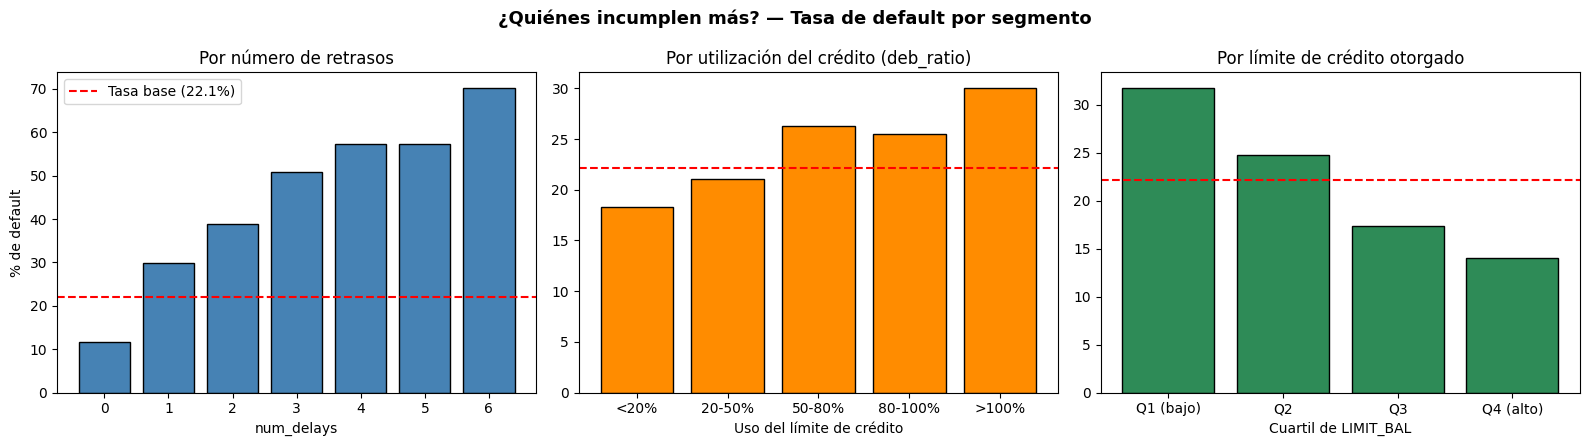

In [ ]:
# ------------------------------------------------------------
# PREGUNTA 1: ¿Quiénes incumplen más?
# Método: agrupar por segmento y calcular la TASA de default
#   df.groupby(grupo)[TARGET].mean()
# El truco: como el target es 0/1, su media ES la proporción
# de defaults del grupo. Se compara siempre contra la tasa base.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('¿Quiénes incumplen más? — Tasa de default por segmento',
             fontsize=13, fontweight='bold')

# a) Por número de retrasos (segmento de comportamiento)
tasa_delays = df.groupby('num_delays')[TARGET].mean() * 100
axes[0].bar(tasa_delays.index, tasa_delays.values, color='steelblue',
            edgecolor='black')
axes[0].axhline(tasa_base*100, color='red', linestyle='--',
                label=f'Tasa base ({tasa_base*100:.1f}%)')
axes[0].set_title('Por número de retrasos')
axes[0].set_xlabel('num_delays')
axes[0].set_ylabel('% de default')
axes[0].legend()

# b) Por nivel de utilización del crédito (deb_ratio en rangos)
df['rango_uso'] = pd.cut(df['deb_ratio'],
                         bins=[-np.inf, 0.2, 0.5, 0.8, 1.0, np.inf],
                         labels=['<20%', '20-50%', '50-80%',
                                 '80-100%', '>100%'])
tasa_uso = df.groupby('rango_uso', observed=True)[TARGET].mean() * 100
axes[1].bar(tasa_uso.index.astype(str), tasa_uso.values,
            color='darkorange', edgecolor='black')
axes[1].axhline(tasa_base*100, color='red', linestyle='--')
axes[1].set_title('Por utilización del crédito (deb_ratio)')
axes[1].set_xlabel('Uso del límite de crédito')

# c) Por límite de crédito (cuartiles)
df['rango_limite'] = pd.qcut(df['LIMIT_BAL'], q=4,
                             labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'])
tasa_lim = df.groupby('rango_limite', observed=True)[TARGET].mean() * 100
axes[2].bar(tasa_lim.index.astype(str), tasa_lim.values,
            color='seagreen', edgecolor='black')
axes[2].axhline(tasa_base*100, color='red', linestyle='--')
axes[2].set_title('Por límite de crédito otorgado')
axes[2].set_xlabel('Cuartil de LIMIT_BAL')

plt.tight_layout()
plt.show()

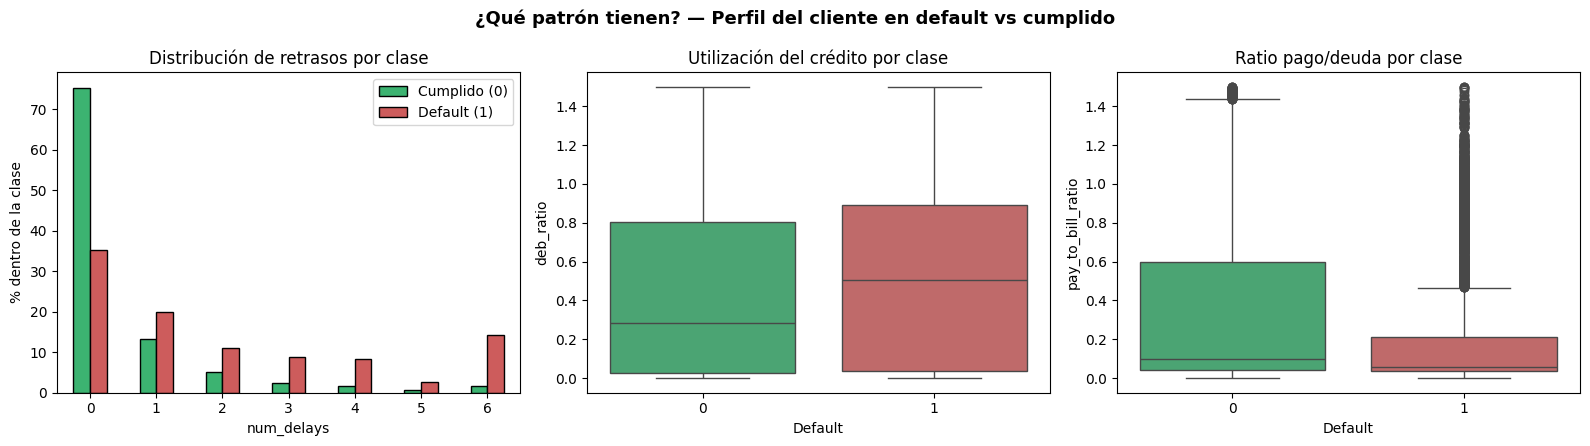

In [ ]:
# ------------------------------------------------------------
# PREGUNTA 2: ¿Qué patrón tienen los que incumplen?
# Método: comparar la DISTRIBUCIÓN de las variables clave entre
# las dos clases. Si la variable "separa", las distribuciones
# se ven distintas. Boxplot para continuas; barras normalizadas
# (% dentro de cada clase) para discretas.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('¿Qué patrón tienen? — Perfil del cliente en default vs cumplido',
             fontsize=13, fontweight='bold')

# a) num_delays: % de clientes dentro de cada clase
#    (normalize dentro de la clase permite comparar pese al desbalance)
tabla = pd.crosstab(df['num_delays'], df[TARGET], normalize='columns') * 100
tabla.plot(kind='bar', ax=axes[0], color=['mediumseagreen', 'indianred'],
           edgecolor='black', rot=0)
axes[0].set_title('Distribución de retrasos por clase')
axes[0].set_xlabel('num_delays')
axes[0].set_ylabel('% dentro de la clase')
axes[0].legend(['Cumplido (0)', 'Default (1)'])

# b) deb_ratio por clase (recortado a [0, 1.5] para legibilidad)
sns.boxplot(data=df[df['deb_ratio'].between(0, 1.5)],
            x=TARGET, y='deb_ratio', ax=axes[1],
            hue=TARGET, palette=['mediumseagreen', 'indianred'], legend=False)
axes[1].set_title('Utilización del crédito por clase')
axes[1].set_xlabel('Default')
axes[1].set_ylabel('deb_ratio')

# c) pay_to_bill_ratio por clase (recortado a [0, 1.5])
sns.boxplot(data=df[df['pay_to_bill_ratio'].between(0, 1.5)],
            x=TARGET, y='pay_to_bill_ratio', ax=axes[2],
            hue=TARGET, palette=['mediumseagreen', 'indianred'], legend=False)
axes[2].set_title('Ratio pago/deuda por clase')
axes[2].set_xlabel('Default')
axes[2].set_ylabel('pay_to_bill_ratio')

plt.tight_layout()
plt.show()

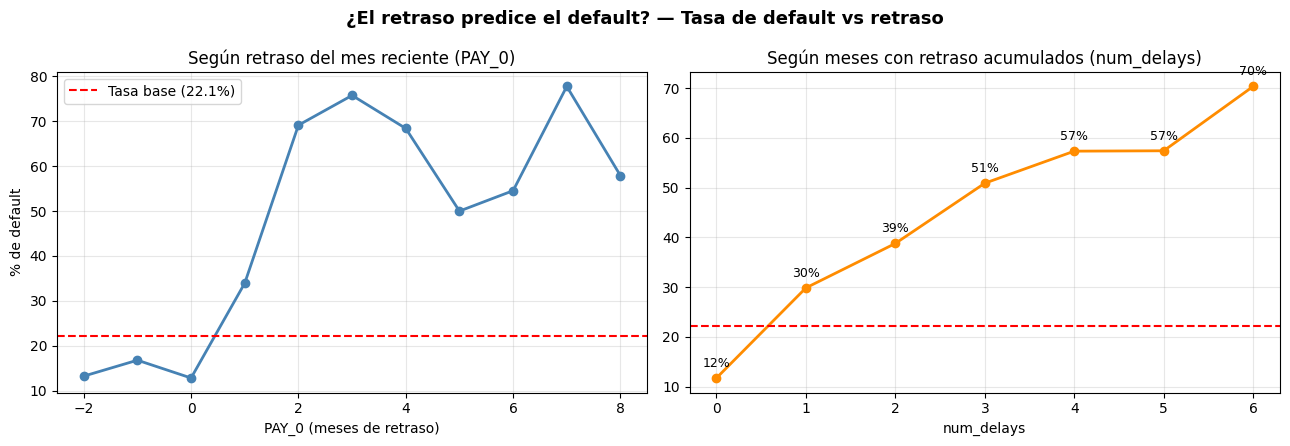

In [36]:
# ------------------------------------------------------------
# PREGUNTA 3: ¿El retraso predice el default?
# Método: para un predictor ordinal, graficar la tasa del target
# EN FUNCIÓN del predictor. Si la curva sube de forma monótona,
# hay señal predictiva clara.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('¿El retraso predice el default? — Tasa de default vs retraso',
             fontsize=13, fontweight='bold')

# a) Tasa de default según PAY_0 (retraso del mes más reciente)
tasa_pay0 = df.groupby('PAY_0')[TARGET].mean() * 100
axes[0].plot(tasa_pay0.index, tasa_pay0.values, marker='o',
             color='steelblue', linewidth=2)
axes[0].axhline(tasa_base*100, color='red', linestyle='--',
                label=f'Tasa base ({tasa_base*100:.1f}%)')
axes[0].set_title('Según retraso del mes reciente (PAY_0)')
axes[0].set_xlabel('PAY_0 (meses de retraso)')
axes[0].set_ylabel('% de default')
axes[0].grid(alpha=0.3)
axes[0].legend()

# b) Tasa de default según num_delays, con el valor anotado
tasa_nd = df.groupby('num_delays')[TARGET].mean() * 100
axes[1].plot(tasa_nd.index, tasa_nd.values, marker='o',
             color='darkorange', linewidth=2)
for x, y in zip(tasa_nd.index, tasa_nd.values):
    axes[1].annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)
axes[1].axhline(tasa_base*100, color='red', linestyle='--')
axes[1].set_title('Según meses con retraso acumulados (num_delays)')
axes[1].set_xlabel('num_delays')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_q3_retraso.png', dpi=110, bbox_inches='tight')
plt.show()

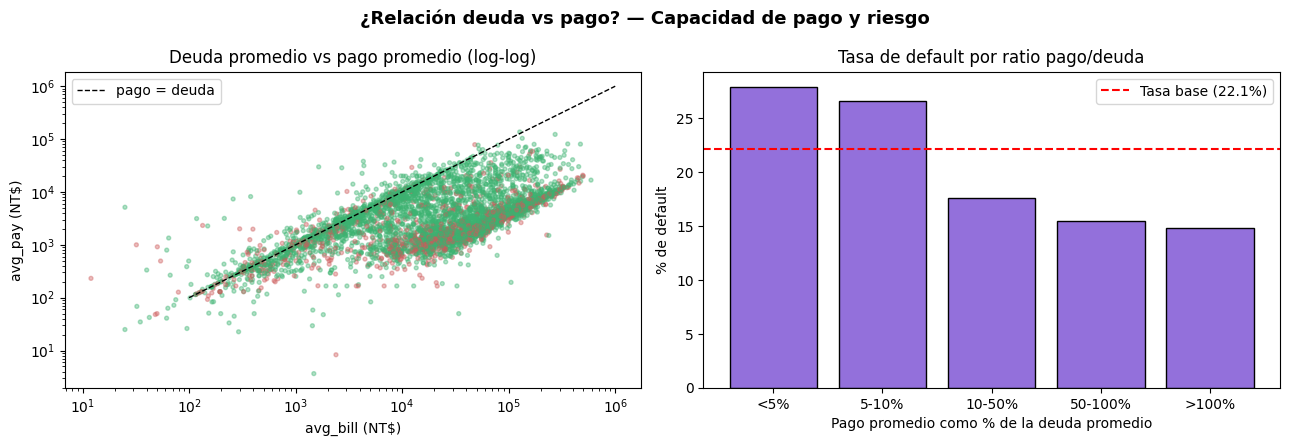

In [37]:
# ------------------------------------------------------------
# PREGUNTA 4: ¿Relación deuda vs pago?
# Método: (a) dispersión deuda vs pago en escala log para ver
# el comportamiento conjunto; (b) discretizar el ratio pago/deuda
# en rangos y volver a la tasa de default por rango — convierte
# una relación continua en una lectura de negocio directa.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('¿Relación deuda vs pago? — Capacidad de pago y riesgo',
             fontsize=13, fontweight='bold')

# a) Dispersión avg_bill vs avg_pay (muestra de 5,000 para legibilidad)
muestra = df[(df['avg_bill'] > 0) & (df['avg_pay'] > 0)].sample(
    5000, random_state=42)
colores = muestra[TARGET].map({0: 'mediumseagreen', 1: 'indianred'})
axes[0].scatter(muestra['avg_bill'], muestra['avg_pay'],
                c=colores, s=8, alpha=0.4)
lims = [1e2, 1e6]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='pago = deuda')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_title('Deuda promedio vs pago promedio (log-log)')
axes[0].set_xlabel('avg_bill (NT$)')
axes[0].set_ylabel('avg_pay (NT$)')
axes[0].legend()

# b) Tasa de default por rango del ratio pago/deuda
df['rango_ratio'] = pd.cut(df['pay_to_bill_ratio'],
                           bins=[-np.inf, 0.05, 0.1, 0.5, 1.0, np.inf],
                           labels=['<5%', '5-10%', '10-50%',
                                   '50-100%', '>100%'])
tasa_ratio = df.groupby('rango_ratio', observed=True)[TARGET].mean() * 100
axes[1].bar(tasa_ratio.index.astype(str), tasa_ratio.values,
            color='mediumpurple', edgecolor='black')
axes[1].axhline(tasa_base*100, color='red', linestyle='--',
                label=f'Tasa base ({tasa_base*100:.1f}%)')
axes[1].set_title('Tasa de default por ratio pago/deuda')
axes[1].set_xlabel('Pago promedio como % de la deuda promedio')
axes[1].set_ylabel('% de default')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_q4_deuda_pago.png', dpi=110, bbox_inches='tight')
plt.show()


In [38]:
# Limpiar columnas auxiliares para no contaminar el df del modelado
df.drop(columns=['rango_uso', 'rango_limite', 'rango_ratio'], inplace=True)